<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/Copia_de_Intro_Python_Modulo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Módulo 1: Fundamentos del Mantenimiento Predictivo y Entorno Analítico
## Introducción a Python para Análisis de Datos de Mantenimiento
### Ingenium Escuela de Formación Profesional · 2026

---

## 🎯 Propósito de este Notebook

Este notebook introduce Python **desde cero**

| Tema del Módulo | Cómo lo trabajamos en Python |
|-----------------|------------------------------|
| **Aplicación del PdM en Gestión de Activos** | Cargar y explorar datos reales de OTs de maquinaria pesada |
| **Introducción a Python para Análisis de Datos** | Variables, estructuras de datos, pandas, visualización |
| **Definición del Problema Analítico** | Formular preguntas analíticas y explorar los datos para responderlas |
| **KPIs y Priorización de Activos** | Calcular MTBF, MTTR, Disponibilidad y Matriz de Criticidad |

---

## 📂 Datos que usaremos

| Archivo | Descripción | Registros |
|---------|-------------|----------|
| **BD_tiempos.csv** | Órdenes de trabajo de maquinaria pesada con tiempos de falla | 616 OTs |
| **bd_fallas.csv** | Registro de fallas con tipos y modos de falla | 674 OTs |

> Datos reales de operación de grúas, cargadores frontales y excavadoras.

---

> **📌 Instrucciones:**
> - Ejecuta cada celda con `Shift + Enter`
> - Los comentarios `#` explican cada línea de código — léelos
> - 🏋️ = Ejercicio a completar · ✅ = Solución · 🧠 = Cuestionario interactivo
> - Usa **ChatGPT** como apoyo si tienes dudas sobre el código

---
## ⚙️ Paso 0: Configurar el Entorno

Antes de analizar datos, importamos las librerías necesarias.
En Python, una **librería** es un conjunto de herramientas ya programadas que podemos usar.

In [ ]:
# ============================================================
# CONFIGURACIÓN DEL ENTORNO
# Importar las librerías necesarias para el Módulo 1
# ============================================================

# pandas: librería para manipular tablas de datos (DataFrames)
# Es el equivalente de Excel pero programable
import pandas as pd

# numpy: librería para cálculos matemáticos y estadísticos
import numpy as np
np.mean
# matplotlib: librería para crear gráficos y visualizaciones
import matplotlib.pyplot as plt

# warnings: para suprimir mensajes de advertencia no críticos
import warnings
warnings.filterwarnings('ignore')   # ignorar advertencias menores

# Configuración visual para los gráficos
plt.rcParams['figure.figsize'] = (12, 5)   # tamaño por defecto de los gráficos
plt.rcParams['font.size'] = 11             # tamaño de fuente
plt.rcParams['axes.spines.top'] = False    # quitar borde superior
plt.rcParams['axes.spines.right'] = False  # quitar borde derecho

# Colores corporativos Ingenium
COLOR_PRINCIPAL = '#9B004C'   # magenta Ingenium
COLOR_SECUNDARIO = '#C4005E'  # magenta claro
COLOR_GRIS = '#D4D4D4'        # gris para comparaciones

# Verificar que todo se importó correctamente
print('✅ Librerías importadas correctamente')
print(f'   pandas  versión: {pd.__version__}')
print(f'   numpy   versión: {np.__version__}')
print()
print('📌 Recuerda: sube los archivos BD_tiempos.csv y bd_fallas.csv')
print('   a Google Colab antes de continuar (ícono de carpeta → subir archivo)')

✅ Librerías importadas correctamente
   pandas  versión: 2.2.2
   numpy   versión: 2.0.2

📌 Recuerda: sube los archivos BD_tiempos.csv y bd_fallas.csv
   a Google Colab antes de continuar (ícono de carpeta → subir archivo)


---
# TEMA 1: Aplicación del PdM en la Gestión de Activos
## Paso 1: Cargar los Datos Reales

El primer paso en cualquier análisis de datos es **cargar y entender los datos disponibles**.
Esto corresponde a la **Fase 2 del CRISP-DM: Comprensión de los Datos**.

### ¿Qué es un DataFrame?
Un **DataFrame** es una tabla de datos en Python (como una hoja de Excel):
- Cada **fila** es un registro (en nuestro caso, una Orden de Trabajo)
- Cada **columna** es una variable (código, activo, tipo de falla, tiempo, etc.)

In [ ]:
# ============================================================
# CARGAR EL DATASET BD_tiempos.csv
# Órdenes de trabajo de maquinaria pesada industrial
# ============================================================

# pd.read_csv() lee un archivo CSV y lo convierte en un DataFrame
# encoding='latin-1' es necesario porque el archivo tiene caracteres especiales (tildes)
df = pd.read_csv('BD_tiempos.csv', encoding='latin-1')

# Renombrar columnas para que sean más fáciles de usar en el código
# Los nombres originales tienen caracteres especiales que complican el análisis
df = df.rename(columns={
    'Descripción De Activos': 'Descripcion_Activo',  # nombre descriptivo del activo
    'Comenzar Trabajo en':    'Fecha_Inicio',         # cuándo empezó la OT
    'Completada en:':         'Fecha_Fin',            # cuándo terminó la OT
    'Tipo Falla':             'Tipo_Falla',           # categoría de la falla
    'Asset Type Code':        'Tipo_Activo',          # código del tipo de activo
    'Tiempo de Falla':        'Tiempo_Falla_min'      # duración de la falla en minutos
})

# Convertir el tiempo de minutos a horas (más fácil de interpretar)
# Dividimos cada valor de la columna entre 60
df['Tiempo_Falla_h'] = df['Tiempo_Falla_min'] / 60

# Convertir las fechas de texto a formato fecha de Python
df['Fecha_Inicio'] = pd.to_datetime(df['Fecha_Inicio'], dayfirst=True, errors='coerce')
df['Fecha_Fin']    = pd.to_datetime(df['Fecha_Fin'],    dayfirst=True, errors='coerce')

# Mostrar información básica del dataset
print('✅ Dataset BD_tiempos.csv cargado correctamente')
print(f'   Filas (OTs):   {df.shape[0]:,}')   # shape[0] = número de filas
print(f'   Columnas:      {df.shape[1]}')      # shape[1] = número de columnas
print()
print('📋 Primeras 5 filas del dataset:')
display(df.head())   # head() muestra las primeras 5 filas por defecto

✅ Dataset BD_tiempos.csv cargado correctamente
   Filas (OTs):   616
   Columnas:      11

📋 Primeras 5 filas del dataset:


,Codigo OT,DescripciÂ¢n,DescripciÂ¢n De Activos,Activo,Fecha_Inicio,Fecha_Fin,Tipo_Falla,Falla,Tipo_Activo,Tiempo_Falla_min,Tiempo_Falla_h
0,R25156,MANTENIMIENTO A CAMARA DE PLUMA DE GRUA,Grua Liebherr,1.1-GRU06,2023-01-26 11:00:00,2023-01-26 12:00:00,Electrico/Instrumentacion,Opaque (Discolour / Unclear),GRUALIEB,60,1.000000
1,R25208,ReparaciÂ¢n de baja presiÂ¢n en sistema de com...,Grua Liebherr,1.1-GRU06,2023-02-02 12:00:00,2023-03-11 02:45:00,Mecanico,Baja Potencia.,GRUALIEB,52725,878.750000
2,R25338,Reemplazo de neumatico daÂ¤ado seccion #51,Grua Liebherr,1.1-GRU06,2023-02-14 19:30:00,2023-02-14 22:00:00,Hidraulico/Neumatico,Pinchado,GRUALIEB,150,2.500000
3,R25357,HABILITADO DE NEUMATICO PARA STOCK,Grua Liebherr,1.1-GRU06,2023-02-18 01:00:00,2023-02-18 13:30:00,Hidraulico/Neumatico,"Fugas, Hidr./Neum.",GRUALIEB,750,12.500000
4,R25531,REMPLAZO DE MANGUERA HIDRAULICA EN FRENO,Grua Liebherr,1.1-GRU06,2023-03-06 11:49:00,2023-03-31 17:00:00,Hidraulico/Neumatico,"Fugas, Hidr./Neum.",GRUALIEB,36311,605.183333


In [ ]:
# ============================================================
# EXPLORACIÓN INICIAL DEL DATASET
# Fase 2 CRISP-DM: Comprensión de los Datos
# ============================================================

print('=== EXPLORACIÓN INICIAL — BD_tiempos.csv ===')
print()

# 1. ¿Qué columnas tenemos y de qué tipo son?
print('1. Columnas y tipos de datos:')
print(df.dtypes.to_string())   # dtypes muestra el tipo de cada columna
print()

# 2. ¿Hay valores faltantes (nulos)?
# En datos reales siempre hay que verificar esto antes de calcular KPIs
print('2. Valores nulos por columna:')
nulos = df.isnull().sum()   # isnull() detecta nulos, sum() los cuenta
if nulos.sum() == 0:
    print('   ✅ No hay valores nulos — dataset completo')
else:
    print(nulos[nulos > 0].to_string())   # mostrar solo columnas con nulos
print()

# 3. ¿Cuántos activos únicos hay en la flota?
# nunique() cuenta los valores únicos de una columna
n_activos = df['Tipo_Activo'].nunique()
print(f'3. Tipos de activo en la flota: {n_activos}')
print(f'   {list(df["Tipo_Activo"].unique())}')
print()

# 4. ¿Cuántos tipos de falla hay?
print('4. Tipos de falla registrados:')
# value_counts() cuenta cuántas veces aparece cada valor
print(df['Tipo_Falla'].value_counts().to_string())
print()

# 5. Estadísticas del tiempo de falla
print('5. Estadísticas del Tiempo de Falla (horas):')
stats = df['Tiempo_Falla_h'].describe()   # describe() calcula estadísticas básicas
print(f'   Mínimo:    {stats["min"]:.2f} h')
print(f'   Mediana:   {stats["50%"]:.2f} h  ← usaremos esta para MTTR (robusta a outliers)')
print(f'   Promedio:  {stats["mean"]:.2f} h  ← distorsionado por valores extremos')
print(f'   Máximo:    {stats["max"]:.2f} h  ({stats["max"]/24:.0f} días)')

=== EXPLORACIÓN INICIAL — BD_tiempos.csv ===

1. Columnas y tipos de datos:
Codigo OT                          object
DescripciÂ¢n                       object
DescripciÂ¢n De Activos            object
Activo                             object
Fecha_Inicio               datetime64[ns]
Fecha_Fin                  datetime64[ns]
Tipo_Falla                         object
Falla                              object
Tipo_Activo                        object
Tiempo_Falla_min                    int64
Tiempo_Falla_h                    float64

2. Valores nulos por columna:
   ✅ No hay valores nulos — dataset completo

3. Tipos de activo en la flota: 9
   ['GRUALIEB', 'CAR938K', 'CAR950K', 'CAR980K', 'CAR980M', 'TRANVX8040', 'EXC320', 'EXC320D', 'EXC320E']

4. Tipos de falla registrados:
Tipo_Falla
Mecanico                     357
Hidraulico/Neumatico         144
Electrico/Instrumentacion     99
Sin Error                      9
Estructural/Civil              7

5. Estadísticas del Tiempo de Falla 

📊 Resumen por tipo de activo:


,n_OTs,tiempo_mediano_h
Tipo_Activo,,
CAR980K,151,3.00
CAR980M,115,2.00
CAR938K,89,2.00
TRANVX8040,78,3.00
EXC320E,55,2.00
EXC320D,52,2.75
GRUALIEB,44,5.55
CAR950K,18,4.25
EXC320,14,4.42


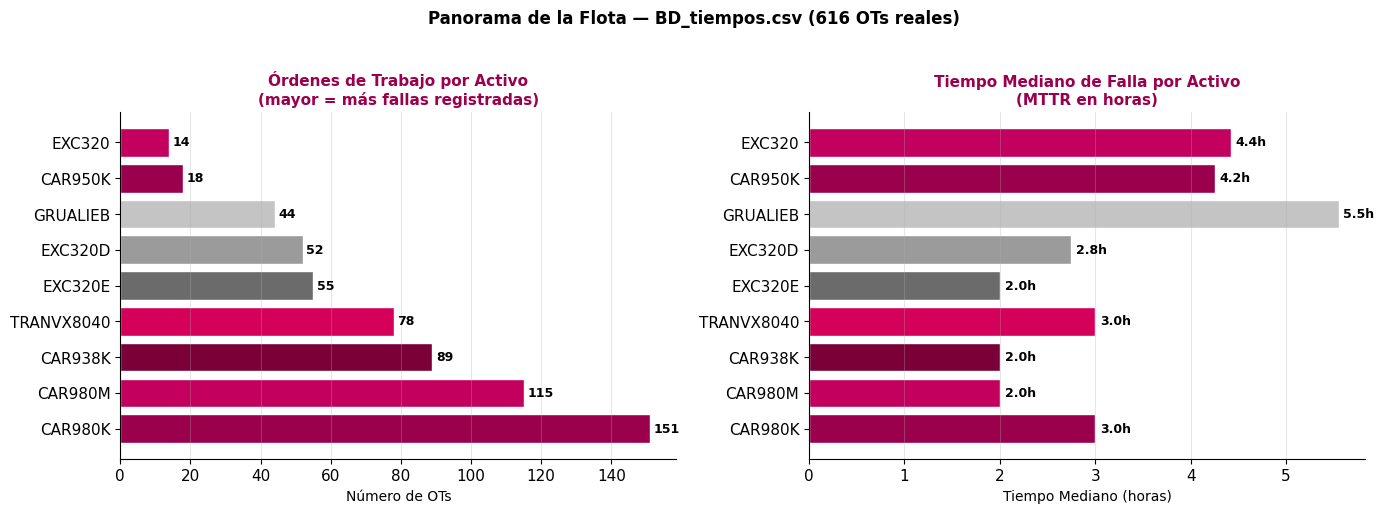

In [ ]:
# ============================================================
# VISUALIZACIÓN: Panorama general de la flota
# ¿Qué activos tienen más fallas y cuánto tiempo tardan en repararse?
# ============================================================

# Calcular OTs y tiempo mediano por tipo de activo
# groupby() agrupa las filas por tipo de activo
# agg() aplica múltiples funciones a la vez
resumen_activos = df.groupby('Tipo_Activo').agg(
    n_OTs=('Codigo OT', 'count'),              # contar OTs por activo
    tiempo_mediano_h=('Tiempo_Falla_h', 'median')  # mediana del tiempo de falla
).round(2).sort_values('n_OTs', ascending=False)  # ordenar de mayor a menor

print('📊 Resumen por tipo de activo:')
display(resumen_activos)

# Crear gráfico de dos paneles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: número de OTs por activo
colores = [COLOR_PRINCIPAL, COLOR_SECUNDARIO, '#7B0038',
           '#D4005A', '#6B6B6B', '#9B9B9B', '#C4C4C4']
axes[0].barh(
    resumen_activos.index,          # activos en el eje Y
    resumen_activos['n_OTs'],       # número de OTs en el eje X
    color=colores[:len(resumen_activos)],
    edgecolor='white'
)
axes[0].set_title('Órdenes de Trabajo por Activo\n(mayor = más fallas registradas)',
                  fontsize=11, fontweight='bold', color=COLOR_PRINCIPAL)
axes[0].set_xlabel('Número de OTs', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='x')
# Agregar etiquetas con el valor
for i, val in enumerate(resumen_activos['n_OTs']):
    axes[0].text(val + 1, i, str(val), va='center', fontweight='bold', fontsize=9)

# Panel derecho: tiempo mediano de falla por activo
axes[1].barh(
    resumen_activos.index,
    resumen_activos['tiempo_mediano_h'],
    color=colores[:len(resumen_activos)],
    edgecolor='white'
)
axes[1].set_title('Tiempo Mediano de Falla por Activo\n(MTTR en horas)',
                  fontsize=11, fontweight='bold', color=COLOR_PRINCIPAL)
axes[1].set_xlabel('Tiempo Mediano (horas)', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')
for i, val in enumerate(resumen_activos['tiempo_mediano_h']):
    axes[1].text(val + 0.05, i, f'{val:.1f}h', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Panorama de la Flota — BD_tiempos.csv (616 OTs reales)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# TEMA 2: Introducción a Python para Análisis de Datos
## Paso 2: Operaciones Fundamentales con Pandas

Pandas es la herramienta principal para analizar datos de mantenimiento en Python.
Aprenderemos las operaciones más usadas aplicadas directamente a nuestros datos reales.

> **Fuente:** McKinney, W. (2022). *Python for Data Analysis*, 3rd ed. O'Reilly Media.

In [ ]:
# ============================================================
# OPERACIÓN 1: SELECCIONAR COLUMNAS
# ¿Cómo elegir solo las columnas que necesito?
# ============================================================

print('=== SELECCIÓN DE COLUMNAS ===')
print()

# Seleccionar una sola columna → devuelve una Serie (lista de valores)
tipos_falla = df['Tipo_Falla']   # columna de tipos de falla
print('Una columna (Serie):')
print(tipos_falla.head(5).to_string())   # mostrar primeros 5 valores
print()

# Seleccionar varias columnas → devuelve un DataFrame
# Se pasa una lista de nombres de columnas entre dobles corchetes [[ ]]
columnas_clave = df[['Codigo OT', 'Tipo_Activo', 'Tipo_Falla', 'Tiempo_Falla_h']]
print('Varias columnas (DataFrame):')
display(columnas_clave.head(5))
print()

# Renombrar columnas para el reporte
# Útil para presentar resultados con nombres más claros
columnas_reporte = columnas_clave.rename(columns={
    'Codigo OT': 'OT',
    'Tipo_Activo': 'Activo',
    'Tipo_Falla': 'Tipo Falla',
    'Tiempo_Falla_h': 'Tiempo (h)'
})
print('Con nombres renombrados para reporte:')
display(columnas_reporte.head(3))

=== SELECCIÓN DE COLUMNAS ===

Una columna (Serie):
0    Electrico/Instrumentacion
1                     Mecanico
2         Hidraulico/Neumatico
3         Hidraulico/Neumatico
4         Hidraulico/Neumatico

Varias columnas (DataFrame):


,Codigo OT,Tipo_Activo,Tipo_Falla,Tiempo_Falla_h
0,R25156,GRUALIEB,Electrico/Instrumentacion,1.000000
1,R25208,GRUALIEB,Mecanico,878.750000
2,R25338,GRUALIEB,Hidraulico/Neumatico,2.500000
3,R25357,GRUALIEB,Hidraulico/Neumatico,12.500000
4,R25531,GRUALIEB,Hidraulico/Neumatico,605.183333



Con nombres renombrados para reporte:


,OT,Activo,Tipo Falla,Tiempo (h)
0,R25156,GRUALIEB,Electrico/Instrumentacion,1.00
1,R25208,GRUALIEB,Mecanico,878.75
2,R25338,GRUALIEB,Hidraulico/Neumatico,2.50


In [ ]:
# ============================================================
# OPERACIÓN 2: FILTRAR FILAS
# ¿Cómo seleccionar solo los registros que me interesan?
# ============================================================

print('=== FILTRADO DE FILAS ===')
print()

# Filtro simple: solo fallas mecánicas
# La condición df['Tipo_Falla'] == 'Mecanico' devuelve True/False para cada fila
# El corchete externo selecciona solo las filas donde la condición es True
df_mecanicas = df[df['Tipo_Falla'] == 'Mecanico']
print(f'Fallas mecánicas: {len(df_mecanicas)} OTs de {len(df)} totales')
print(f'Porcentaje: {len(df_mecanicas)/len(df)*100:.1f}%')
print()

# Filtro por activo: solo Grúas Liebherr
df_grua = df[df['Tipo_Activo'] == 'GRUALIEB']
print(f'OTs de Grúa Liebherr: {len(df_grua)}')
print()

# Filtro combinado: fallas mecánicas en cargadores 980K
# El operador & combina dos condiciones (ambas deben ser True)
df_mec_980K = df[(df['Tipo_Falla'] == 'Mecanico') & (df['Tipo_Activo'] == 'CAR980K')]
print(f'Fallas mecánicas en CAR980K: {len(df_mec_980K)} OTs')
print()

# Filtro por lista de valores: todos los cargadores frontales
# isin() verifica si el valor está en una lista
cargadores = ['CAR980K', 'CAR980M', 'CAR938K']
df_cargadores = df[df['Tipo_Activo'].isin(cargadores)]
print(f'OTs de todos los cargadores frontales: {len(df_cargadores)}')
print()

# Filtro numérico: fallas con tiempo > 24 horas (más de 1 día)
df_largas = df[df['Tiempo_Falla_h'] > 24]
print(f'Fallas de más de 24 horas: {len(df_largas)} OTs')
print(f'Tiempo máximo: {df_largas["Tiempo_Falla_h"].max():.1f} horas ({df_largas["Tiempo_Falla_h"].max()/24:.0f} días)')

=== FILTRADO DE FILAS ===

Fallas mecánicas: 357 OTs de 616 totales
Porcentaje: 58.0%

OTs de Grúa Liebherr: 44

Fallas mecánicas en CAR980K: 85 OTs

OTs de todos los cargadores frontales: 355

Fallas de más de 24 horas: 135 OTs
Tiempo máximo: 7729.5 horas (322 días)


In [ ]:
# ============================================================
# OPERACIÓN 3: AGRUPAR Y CALCULAR (groupby)
# ¿Cómo calcular estadísticas por grupo de activos?
# Esta es la operación más importante para calcular KPIs
# ============================================================

print('=== AGRUPACIÓN Y CÁLCULO (groupby) ===')
print()

# groupby('columna') agrupa las filas por los valores de esa columna
# Luego aplicamos una función a cada grupo

# Ejemplo 1: Contar OTs por tipo de falla
print('OTs por tipo de falla:')
ots_por_falla = df.groupby('Tipo_Falla')['Codigo OT'].count()
print(ots_por_falla.sort_values(ascending=False).to_string())
print()

# Ejemplo 2: Tiempo mediano de falla por tipo de activo
# La mediana es más robusta que el promedio cuando hay valores extremos
print('Tiempo mediano de falla (MTTR) por activo:')
mttr_por_activo = df.groupby('Tipo_Activo')['Tiempo_Falla_h'].median().round(2)
print(mttr_por_activo.sort_values(ascending=False).to_string())
print()

# Ejemplo 3: Múltiples estadísticas a la vez con agg()
# agg() permite calcular varias métricas en una sola operación
print('Resumen completo por tipo de activo:')
resumen = df.groupby('Tipo_Activo').agg(
    n_fallas=('Codigo OT', 'count'),              # contar OTs
    mttr_mediano_h=('Tiempo_Falla_h', 'median'),  # mediana del tiempo
    tiempo_total_h=('Tiempo_Falla_h', 'sum'),      # suma total de horas
    tiempo_max_h=('Tiempo_Falla_h', 'max')         # tiempo máximo
).round(2).sort_values('n_fallas', ascending=False)

display(resumen)
print()
print(f'Total de horas de paro en toda la flota: {df["Tiempo_Falla_h"].sum():.1f} horas')
print(f'Equivalente a: {df["Tiempo_Falla_h"].sum()/24:.1f} días de paro')

=== AGRUPACIÓN Y CÁLCULO (groupby) ===

OTs por tipo de falla:
Tipo_Falla
Mecanico                     357
Hidraulico/Neumatico         144
Electrico/Instrumentacion     99
Sin Error                      9
Estructural/Civil              7

Tiempo mediano de falla (MTTR) por activo:
Tipo_Activo
GRUALIEB      5.55
EXC320        4.42
CAR950K       4.25
TRANVX8040    3.00
CAR980K       3.00
EXC320D       2.75
CAR938K       2.00
CAR980M       2.00
EXC320E       2.00

Resumen completo por tipo de activo:


,n_fallas,mttr_mediano_h,tiempo_total_h,tiempo_max_h
Tipo_Activo,,,,
CAR980K,151,3.00,34283.43,4714.83
CAR980M,115,2.00,26001.82,6954.50
CAR938K,89,2.00,19468.02,7729.50
TRANVX8040,78,3.00,10827.97,3673.50
EXC320E,55,2.00,7414.33,3394.50
EXC320D,52,2.75,13449.03,4872.85
GRUALIEB,44,5.55,10923.85,2743.65
CAR950K,18,4.25,5932.55,4751.47
EXC320,14,4.42,317.65,195.50



Total de horas de paro en toda la flota: 128618.7 horas
Equivalente a: 5359.1 días de paro


In [ ]:
# ============================================================
# OPERACIÓN 4: CREAR NUEVAS COLUMNAS
# ¿Cómo calcular variables derivadas a partir de los datos?
# ============================================================

print('=== CREAR NUEVAS COLUMNAS ===')
print()

# Columna: costo estimado de cada falla
# Multiplicamos el tiempo de falla por el costo por hora
COSTO_HORA_USD = 125_000   # USD/hora (ABB Value of Reliability Survey, 2023)
df['Costo_Estimado_USD'] = df['Tiempo_Falla_h'] * COSTO_HORA_USD
print(f'Columna Costo_Estimado_USD creada')
print(f'Costo total de todas las fallas: ${df["Costo_Estimado_USD"].sum():,.0f} USD')
print()

# Columna: clasificar la falla por duración
# Usamos pd.cut() para crear categorías basadas en rangos numéricos
df['Categoria_Duracion'] = pd.cut(
    df['Tiempo_Falla_h'],
    bins=[0, 2, 8, 24, float('inf')],                    # límites de los rangos
    labels=['Corta (<2h)', 'Media (2-8h)', 'Larga (8-24h)', 'Muy larga (>24h)']  # etiquetas
)

print('Distribución de fallas por duración:')
print(df['Categoria_Duracion'].value_counts().to_string())
print()

# Columna: mes de la falla (para análisis temporal)
# dt.month extrae el mes de una columna de fechas
df['Mes'] = df['Fecha_Inicio'].dt.month
df['Mes_Nombre'] = df['Fecha_Inicio'].dt.strftime('%B')   # nombre del mes

print('OTs por mes (primeros 6 meses):')
ots_mes = df.groupby('Mes')['Codigo OT'].count().head(6)
print(ots_mes.to_string())

print()
print('Vista del DataFrame con nuevas columnas:')
display(df[['Codigo OT', 'Tipo_Activo', 'Tiempo_Falla_h',
            'Costo_Estimado_USD', 'Categoria_Duracion']].head(5))

=== CREAR NUEVAS COLUMNAS ===

Columna Costo_Estimado_USD creada
Costo total de todas las fallas: $16,077,331,250 USD

Distribución de fallas por duración:
Categoria_Duracion
Corta (<2h)         282
Media (2-8h)        151
Muy larga (>24h)    135
Larga (8-24h)        48

OTs por mes (primeros 6 meses):
Mes
1    66
2    73
3    69
4    56
5    83
6    60

Vista del DataFrame con nuevas columnas:


,Codigo OT,Tipo_Activo,Tiempo_Falla_h,Costo_Estimado_USD,Categoria_Duracion
0,R25156,GRUALIEB,1.000000,1.250000e+05,Corta (<2h)
1,R25208,GRUALIEB,878.750000,1.098438e+08,Muy larga (>24h)
2,R25338,GRUALIEB,2.500000,3.125000e+05,Media (2-8h)
3,R25357,GRUALIEB,12.500000,1.562500e+06,Larga (8-24h)
4,R25531,GRUALIEB,605.183333,7.564792e+07,Muy larga (>24h)


### 🏋️ EJERCICIO 2.1 — Análisis Exploratorio con Pandas

**Contexto:** Usando los datos reales de BD_tiempos.csv, responde las siguientes preguntas con pandas.
Cada respuesta debe ser una o dos líneas de código.

In [ ]:
# 🏋️ EJERCICIO 2.1 — Completa cada línea
# ============================================================

print('🏋️ EJERCICIO 2.1: Análisis Exploratorio')
print('='*55)

# Pregunta 1: ¿Cuántas OTs hay por tipo de activo?
print('\n1. OTs por tipo de activo:')
ots_activo = df['Tipo_Activo'].value_counts()   # usa value_counts() sobre la columna Tipo_Activo
print(ots_activo)

# Pregunta 2: ¿Cuál es el tiempo mediano de falla para fallas hidráulicas?
print('\n2. Tiempo mediano de fallas Hidráulico/Neumático:')
tiempo_hidraulico = df[df['Tipo_Falla'] == 'Hidraulico/Neumatico']['Tiempo_Falla_h'].median()   # filtra por Tipo_Falla y calcula la mediana
print(f'   {tiempo_hidraulico:.2f} horas')

# Pregunta 3: ¿Cuál es el costo total estimado por tipo de activo?
print('\n3. Costo total estimado por tipo de activo:')
costo_activo = df.groupby('Tipo_Activo')['Costo_Estimado_USD'].sum()   # usa groupby y sum sobre Costo_Estimado_USD
print(costo_activo.sort_values(ascending=False).to_string())

# Pregunta 4: ¿Cuántas fallas duran más de 8 horas?
print('\n4. Fallas de más de 8 horas:')
fallas_largas = len(df[df['Tiempo_Falla_h'] > 8])   # filtra y cuenta
print(f'   {fallas_largas} OTs ({fallas_largas/len(df)*100:.1f}% del total)')

# Pregunta 5: ¿Cuál es el modo de falla más frecuente?
print('\n5. Top 5 modos de falla más frecuentes:')
top_fallas = df['Falla'].value_counts()   # usa value_counts() sobre la columna Falla
print(top_fallas.head(5).to_string())

🏋️ EJERCICIO 2.1: Análisis Exploratorio

1. OTs por tipo de activo:
Tipo_Activo
CAR980K       151
CAR980M       115
CAR938K        89
TRANVX8040     78
EXC320E        55
EXC320D        52
GRUALIEB       44
CAR950K        18
EXC320         14
Name: count, dtype: int64

2. Tiempo mediano de fallas Hidráulico/Neumático:
   3.17 horas

3. Costo total estimado por tipo de activo:
Tipo_Activo
CAR980K       4.285429e+09
CAR980M       3.250227e+09
CAR938K       2.433502e+09
EXC320D       1.681129e+09
GRUALIEB      1.365481e+09
TRANVX8040    1.353496e+09
EXC320E       9.267917e+08
CAR950K       7.415687e+08
EXC320        3.970625e+07

4. Fallas de más de 8 horas:
   183 OTs (29.7% del total)

5. Top 5 modos de falla más frecuentes:
Falla
Fugas, Hidr./Neum.             101
Baja Potencia.                  57
Desgaste                        52
Fuga (combustible/aceite)       48
Abierto / Operado / Fundido     45


In [ ]:
# ✅ SOLUCIÓN EJERCICIO 2.1
# ============================================================

print('✅ SOLUCIÓN EJERCICIO 2.1')
print('='*55)

# 1. OTs por tipo de activo
print('\n1. OTs por tipo de activo:')
ots_activo = df['Tipo_Activo'].value_counts()   # cuenta ocurrencias de cada activo
print(ots_activo.to_string())

# 2. Tiempo mediano de fallas hidráulicas
print('\n2. Tiempo mediano de fallas Hidráulico/Neumático:')
tiempo_hidraulico = df[df['Tipo_Falla'] == 'Hidraulico/Neumatico']['Tiempo_Falla_h'].median()
print(f'   {tiempo_hidraulico:.2f} horas')

# 3. Costo total por activo
print('\n3. Costo total estimado por tipo de activo:')
costo_activo = df.groupby('Tipo_Activo')['Costo_Estimado_USD'].sum()
for activo, costo in costo_activo.sort_values(ascending=False).items():
    print(f'   {activo:<15}: ${costo:>15,.0f} USD')

# 4. Fallas de más de 8 horas
print('\n4. Fallas de más de 8 horas:')
fallas_largas = len(df[df['Tiempo_Falla_h'] > 8])
print(f'   {fallas_largas} OTs ({fallas_largas/len(df)*100:.1f}% del total)')

# 5. Top 5 modos de falla
print('\n5. Top 5 modos de falla más frecuentes:')
top_fallas = df['Falla'].value_counts()
print(top_fallas.head(5).to_string())
print(f'\n   → El modo más frecuente es: "{top_fallas.index[0]}" ({top_fallas.iloc[0]} OTs)')

✅ SOLUCIÓN EJERCICIO 2.1

1. OTs por tipo de activo:
Tipo_Activo
CAR980K       151
CAR980M       115
CAR938K        89
TRANVX8040     78
EXC320E        55
EXC320D        52
GRUALIEB       44
CAR950K        18
EXC320         14

2. Tiempo mediano de fallas Hidráulico/Neumático:
   3.17 horas

3. Costo total estimado por tipo de activo:
   CAR980K        : $  4,285,429,167 USD
   CAR980M        : $  3,250,227,083 USD
   CAR938K        : $  2,433,502,083 USD
   EXC320D        : $  1,681,129,167 USD
   GRUALIEB       : $  1,365,481,250 USD
   TRANVX8040     : $  1,353,495,833 USD
   EXC320E        : $    926,791,667 USD
   CAR950K        : $    741,568,750 USD
   EXC320         : $     39,706,250 USD

4. Fallas de más de 8 horas:
   183 OTs (29.7% del total)

5. Top 5 modos de falla más frecuentes:
Falla
Fugas, Hidr./Neum.             101
Baja Potencia.                  57
Desgaste                        52
Fuga (combustible/aceite)       48
Abierto / Operado / Fundido     45

   → El modo

---
# TEMA 3: Definición del Problema Analítico
## Paso 3: Aplicar el Ciclo CRISP-DM a los Datos Reales

El **CRISP-DM** es la metodología estándar para proyectos de ciencia de datos.
Aquí lo aplicamos directamente a nuestros datos de maquinaria pesada.

> **Fuente:** Chapman, P. et al. (2000). *CRISP-DM 1.0*. SPSS Inc.

In [ ]:
# ============================================================
# FASE 1 CRISP-DM: COMPRENSIÓN DEL NEGOCIO
# Definir formalmente el problema analítico
# ============================================================

# En Python podemos usar diccionarios para estructurar la definición del problema
# Un diccionario guarda pares clave:valor — ideal para fichas y reportes
problema_analitico = {
    'Activo':              'Flota de maquinaria pesada (grúas, cargadores, excavadoras)',
    'Problema de negocio': 'Reducir el tiempo de paro no planificado de la flota',
    'Pregunta analítica':  '¿Qué tipo de falla ocurre más y cuánto tiempo tarda en repararse?',
    'Tipo de problema':    'Análisis descriptivo + cálculo de KPIs',
    'Variable objetivo':   'Tipo_Falla y Tiempo_Falla_h',
    'Criterio de éxito':   'Identificar activos críticos y reducir paros ≥ 30%',
    'Datos disponibles':   f'{len(df)} OTs con tipo de falla, activo y tiempo de reparación'
}

print('📋 FASE 1 CRISP-DM: DEFINICIÓN DEL PROBLEMA ANALÍTICO')
print('='*65)
# Iterar sobre el diccionario para mostrar cada campo
# .items() devuelve pares (clave, valor)
for clave, valor in problema_analitico.items():
    print(f'  {clave:<25}: {valor}')

📋 FASE 1 CRISP-DM: DEFINICIÓN DEL PROBLEMA ANALÍTICO
  Activo                   : Flota de maquinaria pesada (grúas, cargadores, excavadoras)
  Problema de negocio      : Reducir el tiempo de paro no planificado de la flota
  Pregunta analítica       : ¿Qué tipo de falla ocurre más y cuánto tiempo tarda en repararse?
  Tipo de problema         : Análisis descriptivo + cálculo de KPIs
  Variable objetivo        : Tipo_Falla y Tiempo_Falla_h
  Criterio de éxito        : Identificar activos críticos y reducir paros ≥ 30%
  Datos disponibles        : 616 OTs con tipo de falla, activo y tiempo de reparación


📊 FASE 2 CRISP-DM: COMPRENSIÓN DE LOS DATOS

Distribución del Tiempo de Falla (horas):
   25% de las fallas duran menos de: 1.5h
   50% de las fallas duran menos de: 2.9h  (mediana)
   75% de las fallas duran menos de: 15.0h
   90% de las fallas duran menos de: 518.2h
   95% de las fallas duran menos de: 1214.5h
   Máximo: 7729.5h (322 días)

   → Hay valores extremos que distorsionan el promedio
   → Usaremos la MEDIANA para calcular el MTTR (más robusta)


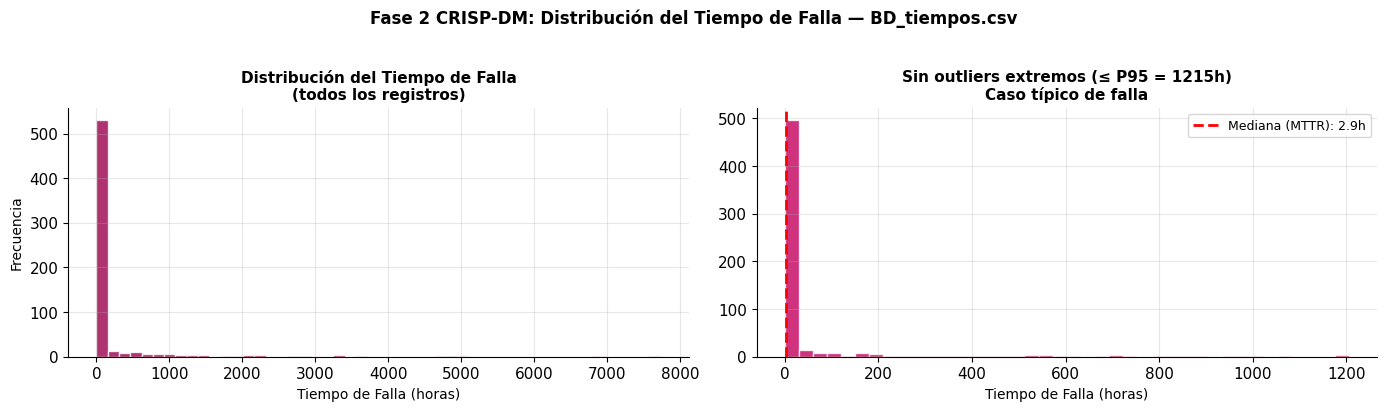

In [ ]:
# ============================================================
# FASE 2 CRISP-DM: COMPRENSIÓN DE LOS DATOS
# Explorar las distribuciones para entender el problema
# ============================================================

print('📊 FASE 2 CRISP-DM: COMPRENSIÓN DE LOS DATOS')
print()

# Distribución de tiempos de falla — detectar outliers
# Los percentiles nos ayudan a entender la distribución
percentiles = df['Tiempo_Falla_h'].quantile([0.25, 0.50, 0.75, 0.90, 0.95])
print('Distribución del Tiempo de Falla (horas):')
print(f'   25% de las fallas duran menos de: {percentiles[0.25]:.1f}h')
print(f'   50% de las fallas duran menos de: {percentiles[0.50]:.1f}h  (mediana)')
print(f'   75% de las fallas duran menos de: {percentiles[0.75]:.1f}h')
print(f'   90% de las fallas duran menos de: {percentiles[0.90]:.1f}h')
print(f'   95% de las fallas duran menos de: {percentiles[0.95]:.1f}h')
print(f'   Máximo: {df["Tiempo_Falla_h"].max():.1f}h ({df["Tiempo_Falla_h"].max()/24:.0f} días)')
print()
print('   → Hay valores extremos que distorsionan el promedio')
print('   → Usaremos la MEDIANA para calcular el MTTR (más robusta)')

# Visualizar la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma completo
axes[0].hist(df['Tiempo_Falla_h'], bins=50,
             color=COLOR_PRINCIPAL, alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución del Tiempo de Falla\n(todos los registros)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tiempo de Falla (horas)', fontsize=10)
axes[0].set_ylabel('Frecuencia', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Sin outliers extremos (mejor visualización del caso típico)
p95 = df['Tiempo_Falla_h'].quantile(0.95)   # percentil 95
df_sin_ext = df[df['Tiempo_Falla_h'] <= p95]  # filtrar outliers extremos
axes[1].hist(df_sin_ext['Tiempo_Falla_h'], bins=40,
             color=COLOR_SECUNDARIO, alpha=0.8, edgecolor='white')
# Línea vertical en la mediana
mediana = df['Tiempo_Falla_h'].median()
axes[1].axvline(mediana, color='red', linestyle='--', linewidth=2,
               label=f'Mediana (MTTR): {mediana:.1f}h')
axes[1].set_title(f'Sin outliers extremos (≤ P95 = {p95:.0f}h)\nCaso típico de falla',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tiempo de Falla (horas)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fase 2 CRISP-DM: Distribución del Tiempo de Falla — BD_tiempos.csv',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FASE 3 CRISP-DM: PREPARACIÓN DE DATOS
# Limpiar y transformar los datos para el análisis de KPIs
# ============================================================

print('🔧 FASE 3 CRISP-DM: PREPARACIÓN DE DATOS')
print()

# Paso 1: Verificar y documentar los tipos de datos
print('1. Tipos de datos de las columnas clave:')
cols_clave = ['Tipo_Activo', 'Tipo_Falla', 'Tiempo_Falla_h', 'Fecha_Inicio']
for col in cols_clave:
    print(f'   {col:<25}: {df[col].dtype}')   # dtype muestra el tipo de dato
print()

# Paso 2: Verificar valores nulos
print('2. Valores nulos en columnas clave:')
nulos_clave = df[cols_clave].isnull().sum()
if nulos_clave.sum() == 0:
    print('   ✅ Sin valores nulos — datos completos para el análisis')
else:
    print(nulos_clave[nulos_clave > 0].to_string())
print()

# Paso 3: Verificar consistencia de los datos
# ¿Hay tiempos de falla negativos o cero? (no tiene sentido físico)
tiempos_invalidos = df[df['Tiempo_Falla_min'] <= 0]
print(f'3. Tiempos de falla inválidos (≤ 0 min): {len(tiempos_invalidos)}')
if len(tiempos_invalidos) == 0:
    print('   ✅ Todos los tiempos son positivos')
print()

# Paso 4: Crear dataset limpio para el análisis de KPIs
# Excluir registros con 'Sin Error' (no son fallas reales)
df_kpis = df[df['Tipo_Falla'] != 'Sin Error'].copy()   # .copy() evita modificar el original
print(f'4. Dataset para KPIs (sin "Sin Error"):')
print(f'   Original: {len(df)} OTs → Limpio: {len(df_kpis)} OTs')
print(f'   Registros excluidos: {len(df) - len(df_kpis)} (tipo "Sin Error")')
print()
print('✅ Datos listos para calcular KPIs')

🔧 FASE 3 CRISP-DM: PREPARACIÓN DE DATOS

1. Tipos de datos de las columnas clave:
   Tipo_Activo              : object
   Tipo_Falla               : object
   Tiempo_Falla_h           : float64
   Fecha_Inicio             : datetime64[ns]

2. Valores nulos en columnas clave:
   ✅ Sin valores nulos — datos completos para el análisis

3. Tiempos de falla inválidos (≤ 0 min): 0
   ✅ Todos los tiempos son positivos

4. Dataset para KPIs (sin "Sin Error"):
   Original: 616 OTs → Limpio: 607 OTs
   Registros excluidos: 9 (tipo "Sin Error")

✅ Datos listos para calcular KPIs


### 🧠 CUESTIONARIO 3 — CRISP-DM y Problema Analítico

In [ ]:
# ============================================================
# 🧠 CUESTIONARIO INTERACTIVO 3 — CRISP-DM
# Las respuestas se calculan dinámicamente desde los datos reales
# ============================================================

# Calcular valores reales para las preguntas
tipo_falla_top = df['Tipo_Falla'].value_counts().index[0]   # tipo más frecuente
n_top = df['Tipo_Falla'].value_counts().iloc[0]             # cuántas veces
mediana_real = df['Tiempo_Falla_h'].median()                # mediana real
promedio_real = df['Tiempo_Falla_h'].mean()                 # promedio real
n_activos_unicos = df['Tipo_Activo'].nunique()              # activos únicos

preguntas = [
    {
        'pregunta': '¿Cuántas fases tiene el ciclo CRISP-DM?',
        'opciones': ['A) 4 fases', 'B) 5 fases', 'C) 6 fases', 'D) 8 fases'],
        'respuesta': 'C',
        'explicacion': 'CRISP-DM tiene 6 fases iterativas: (1) Comprensión del Negocio, (2) Comprensión de los Datos, (3) Preparación de Datos, (4) Modelado, (5) Evaluación y (6) Despliegue. Son iterativas porque se puede volver a fases anteriores.'
    },
    {
        'pregunta': f'En BD_tiempos.csv, ¿cuántos tipos de activo únicos hay en la flota?',
        'opciones': [
            f'A) {n_activos_unicos - 2}',
            f'B) {n_activos_unicos}',
            f'C) {n_activos_unicos + 3}',
            'D) 15'
        ],
        'respuesta': 'B',
        'explicacion': f'El dataset tiene {n_activos_unicos} tipos de activo únicos. Se verifica con: df["Tipo_Activo"].nunique() = {n_activos_unicos}. Los activos son: {list(df["Tipo_Activo"].unique())}'
    },
    {
        'pregunta': f'El promedio del tiempo de falla es {promedio_real:.1f}h pero la mediana es {mediana_real:.1f}h. ¿Por qué usamos la mediana para calcular el MTTR?',
        'opciones': [
            'A) Porque la mediana siempre es menor que el promedio',
            'B) Porque hay fallas extremas que distorsionan el promedio hacia arriba',
            'C) Porque pandas no puede calcular el promedio correctamente',
            'D) Porque la mediana es el estándar ISO para MTTR'
        ],
        'respuesta': 'B',
        'explicacion': f'El dataset tiene fallas de hasta {df["Tiempo_Falla_h"].max():.0f}h ({df["Tiempo_Falla_h"].max()/24:.0f} días). Estos valores extremos elevan el promedio a {promedio_real:.1f}h, muy por encima de la mediana ({mediana_real:.1f}h). La mediana representa mejor el caso típico porque no se ve afectada por outliers.'
    },
    {
        'pregunta': '¿Qué hace el código: df[df["Tipo_Falla"] == "Mecanico"]?',
        'opciones': [
            'A) Elimina las filas con fallas mecánicas del DataFrame',
            'B) Cuenta cuántas fallas mecánicas hay',
            'C) Filtra el DataFrame y devuelve solo las filas con fallas mecánicas',
            'D) Reemplaza "Mecanico" por otro valor'
        ],
        'respuesta': 'C',
        'explicacion': f'df[condicion] filtra el DataFrame y devuelve solo las filas donde la condición es True. En este caso, devuelve las {len(df[df["Tipo_Falla"]=="Mecanico"])} OTs con fallas mecánicas de las {len(df)} totales.'
    }
]

puntaje = 0
print('🧠 CUESTIONARIO 3: CRISP-DM y Problema Analítico')
print('='*60)
print('Escribe la letra de tu respuesta (A, B, C o D)')
print()

for i, q in enumerate(preguntas, 1):
    print(f'Pregunta {i}: {q["pregunta"]}')
    for op in q['opciones']:
        print(f'   {op}')
    respuesta = input('\nTu respuesta: ').strip().upper()
    if respuesta == q['respuesta']:
        print('   ✅ ¡CORRECTO!')
        puntaje += 1
    else:
        print(f'   ❌ Incorrecto. Respuesta correcta: {q["respuesta"]}')
    print(f'   💡 {q["explicacion"]}')
    print()

print('='*60)
print(f'📊 RESULTADO: {puntaje}/{len(preguntas)} ({puntaje/len(preguntas)*100:.0f}%)')
print('🏆 ¡Excelente!' if puntaje == len(preguntas) else '📖 Repasa la Sección 3.')

🧠 CUESTIONARIO 3: CRISP-DM y Problema Analítico
Escribe la letra de tu respuesta (A, B, C o D)

Pregunta 1: ¿Cuántas fases tiene el ciclo CRISP-DM?
   A) 4 fases
   B) 5 fases
   C) 6 fases
   D) 8 fases

Tu respuesta: 5
   ❌ Incorrecto. Respuesta correcta: C
   💡 CRISP-DM tiene 6 fases iterativas: (1) Comprensión del Negocio, (2) Comprensión de los Datos, (3) Preparación de Datos, (4) Modelado, (5) Evaluación y (6) Despliegue. Son iterativas porque se puede volver a fases anteriores.

Pregunta 2: En BD_tiempos.csv, ¿cuántos tipos de activo únicos hay en la flota?
   A) 7
   B) 9
   C) 12
   D) 15

Tu respuesta: A)
   ❌ Incorrecto. Respuesta correcta: B
   💡 El dataset tiene 9 tipos de activo únicos. Se verifica con: df["Tipo_Activo"].nunique() = 9. Los activos son: ['GRUALIEB', 'CAR938K', 'CAR950K', 'CAR980K', 'CAR980M', 'TRANVX8040', 'EXC320', 'EXC320D', 'EXC320E']

Pregunta 3: El promedio del tiempo de falla es 208.8h pero la mediana es 2.9h. ¿Por qué usamos la mediana para calcular

---
# TEMA 4: KPIs y Priorización de Activos
## Paso 4: Calcular KPIs con Python y Pandas

Los **KPIs de mantenimiento** cuantifican el desempeño de los activos.
Los calculamos directamente desde los datos reales de BD_tiempos.csv.

| KPI | Fórmula | Fuente |
|-----|---------|--------|
| **MTTR** | Tiempo total reparación / N° reparaciones | ISO 14224:2016 |
| **MTBF** | Tiempo operación / N° fallas | ISO 14224:2016 |
| **Disponibilidad** | MTBF / (MTBF + MTTR) | ISO 14224:2016 |
| **Criticidad** | Frecuencia × Consecuencia | Moubray (1997) |

In [ ]:
# ============================================================
# CÁLCULO DE KPIs CON PANDAS — DATOS REALES
# Dataset: BD_tiempos.csv (sin registros 'Sin Error')
# ============================================================

# Constantes del sistema (documentadas explícitamente)
HORAS_DISPONIBLES = 6000   # horas/año disponibles para operar (supuesto)
COSTO_HORA_USD = 125_000   # USD/hora de paro (ABB Value of Reliability Survey, 2023)
BENCHMARK_DISP = 95.0      # % de disponibilidad objetivo (industria)

# Calcular KPIs para cada tipo de activo usando groupby
# Primero calculamos las métricas base
kpis_base = df_kpis.groupby('Tipo_Activo').agg(
    n_fallas=('Codigo OT', 'count'),              # número de fallas
    mttr_h=('Tiempo_Falla_h', 'median'),          # MTTR = mediana del tiempo de falla
    tiempo_total_rep_h=('Tiempo_Falla_h', 'sum')  # tiempo total en reparaciones
).round(2)

# Calcular MTBF y Disponibilidad a partir de las métricas base
# Estas operaciones se aplican a toda la columna a la vez (vectorizadas)
kpis_base['tiempo_op_h'] = (HORAS_DISPONIBLES - kpis_base['tiempo_total_rep_h']).clip(lower=0)
kpis_base['mtbf_h'] = (kpis_base['tiempo_op_h'] / kpis_base['n_fallas']).round(1)
kpis_base['disponibilidad_pct'] = (
    kpis_base['mtbf_h'] / (kpis_base['mtbf_h'] + kpis_base['mttr_h']) * 100
).round(2)
kpis_base['costo_total_usd'] = (kpis_base['tiempo_total_rep_h'] * COSTO_HORA_USD).round(0)
kpis_base['cumple_benchmark'] = kpis_base['disponibilidad_pct'] >= BENCHMARK_DISP

# Ordenar por disponibilidad (de menor a mayor para ver los más críticos primero)
kpis_final = kpis_base.sort_values('disponibilidad_pct')

print('🔧 KPIs DE MANTENIMIENTO — MAQUINARIA PESADA INDUSTRIAL')
print(f'   Fuente: BD_tiempos.csv · Supuesto: {HORAS_DISPONIBLES}h/año disponibles')
print('='*75)
print(f'{"Activo":<15} {"Fallas":>7} {"MTTR(h)":>8} {"MTBF(h)":>8} {"Disp%":>7} {"Costo USD":>15} {"Estado":>10}')
print('-'*75)

for activo, row in kpis_final.iterrows():   # iterrows() itera sobre las filas
    estado = '✅ OK' if row['cumple_benchmark'] else '⚠️ CRÍTICO'
    print(f'{activo:<15} {row["n_fallas"]:>7.0f} {row["mttr_h"]:>8.2f} '
          f'{row["mtbf_h"]:>8.1f} {row["disponibilidad_pct"]:>7.2f} '
          f'${row["costo_total_usd"]:>13,.0f} {estado:>10}')

print('-'*75)
print(f'  TOTAL: {kpis_final["n_fallas"].sum():.0f} fallas | '
      f'${kpis_final["costo_total_usd"].sum():,.0f} USD costo total')
print(f'  Benchmark: Disponibilidad > {BENCHMARK_DISP}% (ISO 14224:2016)')
print(f'  Fuente costo: ABB Value of Reliability Survey (2023)')

🔧 KPIs DE MANTENIMIENTO — MAQUINARIA PESADA INDUSTRIAL
   Fuente: BD_tiempos.csv · Supuesto: 6000h/año disponibles
Activo           Fallas  MTTR(h)  MTBF(h)   Disp%       Costo USD     Estado
---------------------------------------------------------------------------
CAR938K              87     2.00      0.0    0.00 $2,427,158,750 ⚠️ CRÍTICO
CAR980K             146     3.00      0.0    0.00 $4,282,516,250 ⚠️ CRÍTICO
CAR980M             113     2.00      0.0    0.00 $3,249,665,000 ⚠️ CRÍTICO
EXC320D              52     2.75      0.0    0.00 $1,681,128,750 ⚠️ CRÍTICO
GRUALIEB             44     5.55      0.0    0.00 $1,365,481,250 ⚠️ CRÍTICO
EXC320E              55     2.00      0.0    0.00 $  926,791,250 ⚠️ CRÍTICO
TRANVX8040           78     3.00      0.0    0.00 $1,353,496,250 ⚠️ CRÍTICO
CAR950K              18     4.25      3.7   46.54 $  741,568,750 ⚠️ CRÍTICO
EXC320               14     4.42    405.9   98.92 $   39,706,250       ✅ OK
------------------------------------------------

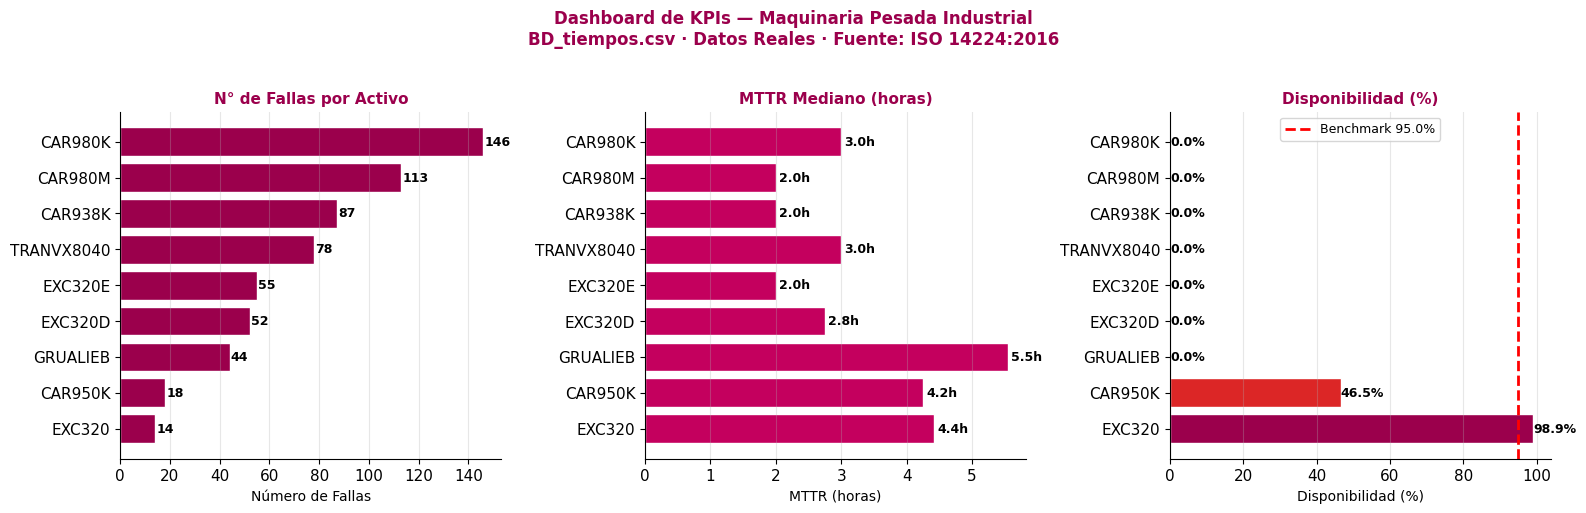

In [ ]:
# ============================================================
# VISUALIZACIÓN: DASHBOARD DE KPIs
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ordenar para la visualización
kpis_viz = kpis_final.sort_values('n_fallas', ascending=True)

# Colores: rojo para activos críticos, magenta para los que cumplen
colores_disp = ['#DC2626' if not ok else COLOR_PRINCIPAL
                for ok in kpis_viz['cumple_benchmark']]

# Panel 1: Número de fallas
axes[0].barh(kpis_viz.index, kpis_viz['n_fallas'],
             color=COLOR_PRINCIPAL, edgecolor='white')
axes[0].set_title('N° de Fallas por Activo', fontsize=11,
                  fontweight='bold', color=COLOR_PRINCIPAL)
axes[0].set_xlabel('Número de Fallas', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='x')
for i, val in enumerate(kpis_viz['n_fallas']):
    axes[0].text(val + 0.5, i, str(int(val)), va='center', fontweight='bold', fontsize=9)

# Panel 2: MTTR mediano
axes[1].barh(kpis_viz.index, kpis_viz['mttr_h'],
             color=COLOR_SECUNDARIO, edgecolor='white')
axes[1].set_title('MTTR Mediano (horas)', fontsize=11,
                  fontweight='bold', color=COLOR_PRINCIPAL)
axes[1].set_xlabel('MTTR (horas)', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')
for i, val in enumerate(kpis_viz['mttr_h']):
    axes[1].text(val + 0.05, i, f'{val:.1f}h', va='center', fontweight='bold', fontsize=9)

# Panel 3: Disponibilidad con benchmark
axes[2].barh(kpis_viz.index, kpis_viz['disponibilidad_pct'],
             color=colores_disp, edgecolor='white')
axes[2].axvline(x=BENCHMARK_DISP, color='red', linestyle='--',
               linewidth=2, label=f'Benchmark {BENCHMARK_DISP}%')
axes[2].set_title('Disponibilidad (%)', fontsize=11,
                  fontweight='bold', color=COLOR_PRINCIPAL)
axes[2].set_xlabel('Disponibilidad (%)', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='x')
for i, val in enumerate(kpis_viz['disponibilidad_pct']):
    axes[2].text(val + 0.1, i, f'{val:.1f}%', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Dashboard de KPIs — Maquinaria Pesada Industrial\n'
             'BD_tiempos.csv · Datos Reales · Fuente: ISO 14224:2016',
             fontsize=12, fontweight='bold', color=COLOR_PRINCIPAL, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MATRIZ DE CRITICIDAD — DATOS REALES bd_fallas.csv
# Criticidad = Frecuencia × Consecuencia
# Fuente: Moubray (1997). RCM2 · SAE JA1011:2009
# ============================================================

# Cargar el dataset de fallas
df_f = pd.read_csv('bd fallas.csv', encoding='latin-1')
df_f = df_f.rename(columns={'Tipo Falla': 'Tipo_Falla', 'Asset Type Code': 'Tipo_Activo'})

# Contar fallas por tipo
conteo = df_f['Tipo_Falla'].value_counts()
freq_max = conteo.max()   # para normalizar a escala 0-10

# Consecuencias definidas por el ingeniero de confiabilidad
# Escala 1-10 basada en impacto en producción, seguridad y costo de reparación
consecuencias = {
    'Mecanico':                  7,   # impacto alto en producción
    'Hidraulico/Neumatico':      8,   # impacto muy alto — puede causar accidentes
    'Electrico/Instrumentacion': 9,   # impacto crítico — afecta control del equipo
    'Estructural/Civil':         6,   # impacto moderado
    'Sin Error':                 1    # sin impacto real
}

# Construir la matriz de criticidad
filas_crit = []   # lista para guardar los resultados
for tipo, consecuencia in consecuencias.items():
    freq_abs = conteo.get(tipo, 0)              # frecuencia absoluta
    freq_rel = (freq_abs / freq_max) * 10       # normalizar a escala 0-10
    criticidad = freq_rel * consecuencia        # fórmula de criticidad

    # Determinar nivel de criticidad
    if criticidad > 50:
        nivel = '🔴 Crítico'
    elif criticidad > 20:
        nivel = '🟡 Importante'
    else:
        nivel = '🟢 Estándar'

    filas_crit.append({
        'Tipo de Falla': tipo,
        'Frecuencia (abs)': int(freq_abs),
        'Frecuencia (0-10)': round(freq_rel, 2),
        'Consecuencia (0-10)': consecuencia,
        'Criticidad': round(criticidad, 2),
        'Nivel': nivel
    })

# Convertir la lista de diccionarios en un DataFrame
df_criticidad = pd.DataFrame(filas_crit).sort_values('Criticidad', ascending=False)

print('📊 MATRIZ DE CRITICIDAD — bd_fallas.csv (674 OTs reales)')
print('   Fórmula: Criticidad = Frecuencia × Consecuencia')
print('   Fuente: Moubray (1997). RCM2 · SAE JA1011:2009')
print()
display(df_criticidad)

print('\n🎯 PRIORIZACIÓN DE INTERVENCIONES:')
for _, row in df_criticidad.iterrows():
    print(f"  {row['Nivel']} | {row['Tipo de Falla']:<35} Criticidad: {row['Criticidad']:.2f}")

📊 MATRIZ DE CRITICIDAD — bd_fallas.csv (674 OTs reales)
   Fórmula: Criticidad = Frecuencia × Consecuencia
   Fuente: Moubray (1997). RCM2 · SAE JA1011:2009



,Tipo de Falla,Frecuencia (abs),Frecuencia (0-10),Consecuencia (0-10),Criticidad,Nivel
0,Mecanico,396,10.00,7,70.00,🔴 Crítico
1,Hidraulico/Neumatico,153,3.86,8,30.91,🟡 Importante
2,Electrico/Instrumentacion,109,2.75,9,24.77,🟡 Importante
3,Estructural/Civil,7,0.18,6,1.06,🟢 Estándar
4,Sin Error,9,0.23,1,0.23,🟢 Estándar



🎯 PRIORIZACIÓN DE INTERVENCIONES:
  🔴 Crítico | Mecanico                            Criticidad: 70.00
  🟡 Importante | Hidraulico/Neumatico                Criticidad: 30.91
  🟡 Importante | Electrico/Instrumentacion           Criticidad: 24.77
  🟢 Estándar | Estructural/Civil                   Criticidad: 1.06
  🟢 Estándar | Sin Error                           Criticidad: 0.23


### 🏋️ EJERCICIO 4.1 — Calcular KPIs por Grupo de Activos

**Contexto:** Tu jefe necesita comparar los KPIs de los **Cargadores Frontales** vs las **Excavadoras**.

In [ ]:
# 🏋️ EJERCICIO 4.1 — Completa el código
# ============================================================

print('🏋️ EJERCICIO 4.1: KPIs por Grupo de Activos')
print('='*55)

# Definir los grupos de activos
cargadores = ['CAR980K', 'CAR980M', 'CAR938K']   # lista de cargadores frontales
excavadoras = ['EXC320D', 'EXC320E']              # lista de excavadoras

# TODO 1: Filtrar el DataFrame para cada grupo
# Pista: usa isin() para filtrar por una lista de valores
df_carg = df[df['Tipo_Activo'].isin(cargadores)]   # filas donde Tipo_Activo está en la lista cargadores
df_exc  = df[df['Tipo_Activo'].isin(excavadoras)]   # filas donde Tipo_Activo está en la lista excavadoras

# TODO 2: Calcular MTTR mediano para cada grupo
mttr_carg = df_carg['Tiempo_Falla_h'].median()   # mediana de Tiempo_Falla_h para cargadores
mttr_exc  = df_exc['Tiempo_Falla_h'].median()   # mediana de Tiempo_Falla_h para excavadoras

# TODO 3: Calcular tasa de falla (fallas por activo)
tasa_carg = len(df_carg) / len(cargadores)   # OTs / número de activos
tasa_exc  = len(df_exc) / len(excavadoras) # OTs / número de activos

# TODO 4: Calcular costo total de cada grupo
costo_carg = df_carg['Costo_Estimado_USD'].sum()   # suma de Costo_Estimado_USD para cargadores
costo_exc  = df_exc['Costo_Estimado_USD'].sum() # suma de Costo_Estimado_USD para excavadoras

# Mostrar resultados
print(f'\n  CARGADORES FRONTALES ({len(df_carg)} OTs, {len(cargadores)} activos):')
print(f'    MTTR mediano:      {mttr_carg:.2f} horas')
print(f'    Fallas por activo: {tasa_carg:.1f}')
print(f'    Costo total:       ${costo_carg:,.0f} USD')

print(f'\n  EXCAVADORAS ({len(df_exc)} OTs, {len(excavadoras)} activos):')
print(f'    MTTR mediano:      {mttr_exc:.2f} horas')
print(f'    Fallas por activo: {tasa_exc:.1f}')
print(f'    Costo total:       ${costo_exc:,.0f} USD')

print('\n  ¿Qué grupo requiere mayor atención? ')

🏋️ EJERCICIO 4.1: KPIs por Grupo de Activos

  CARGADORES FRONTALES (355 OTs, 3 activos):
    MTTR mediano:      2.50 horas
    Fallas por activo: 118.3
    Costo total:       $9,969,158,333 USD

  EXCAVADORAS (107 OTs, 2 activos):
    MTTR mediano:      2.00 horas
    Fallas por activo: 53.5
    Costo total:       $2,607,920,833 USD

  ¿Qué grupo requiere mayor atención? 


In [ ]:
# ✅ SOLUCIÓN EJERCICIO 4.1
# ============================================================

print('✅ SOLUCIÓN EJERCICIO 4.1')
print('='*55)

cargadores = ['CAR980K', 'CAR980M', 'CAR938K']
excavadoras = ['EXC320D', 'EXC320E']

# Filtrar por grupo usando isin()
df_carg = df[df['Tipo_Activo'].isin(cargadores)]
df_exc  = df[df['Tipo_Activo'].isin(excavadoras)]

# Calcular KPIs
mttr_carg = df_carg['Tiempo_Falla_h'].median()
mttr_exc  = df_exc['Tiempo_Falla_h'].median()
tasa_carg = len(df_carg) / len(cargadores)
tasa_exc  = len(df_exc) / len(excavadoras)
costo_carg = df_carg['Costo_Estimado_USD'].sum()
costo_exc  = df_exc['Costo_Estimado_USD'].sum()

print(f'\n  CARGADORES FRONTALES ({len(df_carg)} OTs, {len(cargadores)} activos):')
print(f'    MTTR mediano:      {mttr_carg:.2f} horas')
print(f'    Fallas por activo: {tasa_carg:.1f}')
print(f'    Costo total:       ${costo_carg:,.0f} USD')

print(f'\n  EXCAVADORAS ({len(df_exc)} OTs, {len(excavadoras)} activos):')
print(f'    MTTR mediano:      {mttr_exc:.2f} horas')
print(f'    Fallas por activo: {tasa_exc:.1f}')
print(f'    Costo total:       ${costo_exc:,.0f} USD')

# Interpretación automática basada en los datos
grupo_mayor_mttr = 'Cargadores' if mttr_carg > mttr_exc else 'Excavadoras'
grupo_mayor_freq = 'Cargadores' if tasa_carg > tasa_exc else 'Excavadoras'
grupo_mayor_costo = 'Cargadores' if costo_carg > costo_exc else 'Excavadoras'

print(f'\n  💡 INTERPRETACIÓN:')
print(f'    Mayor MTTR (más tiempo de reparación): {grupo_mayor_mttr}')
print(f'    Mayor frecuencia de fallas por activo: {grupo_mayor_freq}')
print(f'    Mayor costo total de fallas:           {grupo_mayor_costo}')
print(f'    → El grupo con mayor criticidad combinada requiere prioridad en PdM')

✅ SOLUCIÓN EJERCICIO 4.1

  CARGADORES FRONTALES (355 OTs, 3 activos):
    MTTR mediano:      2.50 horas
    Fallas por activo: 118.3
    Costo total:       $9,969,158,333 USD

  EXCAVADORAS (107 OTs, 2 activos):
    MTTR mediano:      2.00 horas
    Fallas por activo: 53.5
    Costo total:       $2,607,920,833 USD

  💡 INTERPRETACIÓN:
    Mayor MTTR (más tiempo de reparación): Cargadores
    Mayor frecuencia de fallas por activo: Cargadores
    Mayor costo total de fallas:           Cargadores
    → El grupo con mayor criticidad combinada requiere prioridad en PdM


### 🧠 CUESTIONARIO 4 — KPIs y Priorización

In [ ]:
# ============================================================
# 🧠 CUESTIONARIO INTERACTIVO 4 — KPIs
# ============================================================

# Valores reales calculados del dataset
activo_mas_fallas = df['Tipo_Activo'].value_counts().index[0]
n_fallas_max = df['Tipo_Activo'].value_counts().iloc[0]
mttr_global = df['Tiempo_Falla_h'].median()
tipo_critico = df_criticidad.iloc[0]['Tipo de Falla']   # tipo más crítico

preguntas_kpi = [
    {
        'pregunta': 'Si un activo tiene MTBF = 500h y MTTR = 10h, ¿cuál es su disponibilidad?',
        'opciones': ['A) 95.0%', 'B) 98.0%', 'C) 50.0%', 'D) 90.0%'],
        'respuesta': 'B',
        'explicacion': 'D = MTBF / (MTBF + MTTR) = 500 / (500 + 10) = 500/510 = 0.9804 = 98.04% ≈ 98.0%. Supera el benchmark de 95%. Fuente: ISO 14224:2016.'
    },
    {
        'pregunta': f'En BD_tiempos.csv, ¿qué tipo de activo tiene más órdenes de trabajo?',
        'opciones': [
            f'A) {df["Tipo_Activo"].value_counts().index[2]} ({df["Tipo_Activo"].value_counts().iloc[2]} OTs)',
            f'B) {df["Tipo_Activo"].value_counts().index[1]} ({df["Tipo_Activo"].value_counts().iloc[1]} OTs)',
            f'C) {activo_mas_fallas} ({n_fallas_max} OTs)',
            f'D) GRUALIEB ({len(df[df["Tipo_Activo"]=="GRUALIEB"])} OTs)'
        ],
        'respuesta': 'C',
        'explicacion': f'El {activo_mas_fallas} tiene {n_fallas_max} OTs — el mayor de la flota. Se verifica con: df["Tipo_Activo"].value_counts().index[0]. Esto lo convierte en candidato prioritario para PdM.'
    },
    {
        'pregunta': '¿Qué fórmula calcula la Criticidad en la Matriz de Criticidad?',
        'opciones': [
            'A) Criticidad = MTBF × MTTR',
            'B) Criticidad = Frecuencia de Falla × Consecuencia',
            'C) Criticidad = Disponibilidad / OEE',
            'D) Criticidad = N° Fallas / Tiempo Total'
        ],
        'respuesta': 'B',
        'explicacion': f'Criticidad = Frecuencia × Consecuencia. En nuestros datos, el tipo más crítico es "{tipo_critico}" porque combina alta frecuencia con alta consecuencia. Fuente: Moubray (1997). RCM2 · SAE JA1011:2009.'
    },
    {
        'pregunta': f'El tiempo mediano de falla es {mttr_global:.1f}h. ¿Qué código pandas lo calcula?',
        'opciones': [
            'A) df["Tiempo_Falla_h"].mean()',
            'B) df["Tiempo_Falla_h"].median()',
            'C) df["Tiempo_Falla_h"].mode()',
            'D) df["Tiempo_Falla_h"].sum() / len(df)'
        ],
        'respuesta': 'B',
        'explicacion': f'.median() = {mttr_global:.2f}h (mediana). .mean() = {df["Tiempo_Falla_h"].mean():.2f}h (promedio, distorsionado por outliers de hasta {df["Tiempo_Falla_h"].max():.0f}h). La mediana es más robusta para datos con valores extremos.'
    }
]

puntaje = 0
print('🧠 CUESTIONARIO 4: KPIs y Priorización de Activos')
print('='*60)
print('Escribe la letra de tu respuesta (A, B, C o D)')
print()

for i, q in enumerate(preguntas_kpi, 1):
    print(f'Pregunta {i}: {q["pregunta"]}')
    for op in q['opciones']:
        print(f'   {op}')
    respuesta = input('\nTu respuesta: ').strip().upper()
    if respuesta == q['respuesta']:
        print('   ✅ ¡CORRECTO!')
        puntaje += 1
    else:
        print(f'   ❌ Incorrecto. Respuesta correcta: {q["respuesta"]}')
    print(f'   💡 {q["explicacion"]}')
    print()

print('='*60)
print(f'📊 RESULTADO: {puntaje}/{len(preguntas_kpi)} ({puntaje/len(preguntas_kpi)*100:.0f}%)')
print('🏆 ¡Excelente!' if puntaje >= 3 else '📖 Repasa la Sección 4.')

🧠 CUESTIONARIO 4: KPIs y Priorización de Activos
Escribe la letra de tu respuesta (A, B, C o D)

Pregunta 1: Si un activo tiene MTBF = 500h y MTTR = 10h, ¿cuál es su disponibilidad?
   A) 95.0%
   B) 98.0%
   C) 50.0%
   D) 90.0%

Tu respuesta: D
   ❌ Incorrecto. Respuesta correcta: B
   💡 D = MTBF / (MTBF + MTTR) = 500 / (500 + 10) = 500/510 = 0.9804 = 98.04% ≈ 98.0%. Supera el benchmark de 95%. Fuente: ISO 14224:2016.

Pregunta 2: En BD_tiempos.csv, ¿qué tipo de activo tiene más órdenes de trabajo?
   A) CAR938K (89 OTs)
   B) CAR980M (115 OTs)
   C) CAR980K (151 OTs)
   D) GRUALIEB (44 OTs)

Tu respuesta: C
   ✅ ¡CORRECTO!
   💡 El CAR980K tiene 151 OTs — el mayor de la flota. Se verifica con: df["Tipo_Activo"].value_counts().index[0]. Esto lo convierte en candidato prioritario para PdM.

Pregunta 3: ¿Qué fórmula calcula la Criticidad en la Matriz de Criticidad?
   A) Criticidad = MTBF × MTTR
   B) Criticidad = Frecuencia de Falla × Consecuencia
   C) Criticidad = Disponibilidad / OE

---
# Ejercicio Integrador Final
## Análisis Completo del Módulo 1 con Datos Reales

**Objetivo:** Integrar los 4 temas del módulo en un análisis coherente.

**Instrucciones:**
1. Selecciona un tipo de activo de la flota
2. Aplica las Fases 1-3 del CRISP-DM
3. Calcula sus KPIs (MTTR, MTBF, Disponibilidad)
4. Calcula el impacto económico de sus fallas
5. Genera 2 visualizaciones con matplotlib
6. Escribe una conclusión con recomendaciones

In [ ]:
# 🏋️ EJERCICIO INTEGRADOR — Análisis completo de un activo
# ============================================================

# Selecciona el activo a analizar
# Opciones: 'CAR980K', 'CAR980M', 'CAR938K', 'TRANVX8040',
#           'EXC320E', 'EXC320D', 'GRUALIEB', 'CAR950K'
ACTIVO = 'CAR980K'   # cambia este valor

# Filtrar datos del activo seleccionado
df_activo = df[df['Tipo_Activo'] == ACTIVO].copy()

print(f'📊 ANÁLISIS INTEGRADOR — {ACTIVO}')
print(f'   Total de OTs: {len(df_activo)}')
print()

# FASE 1 CRISP-DM: Comprensión del negocio
print('FASE 1: COMPRENSIÓN DEL NEGOCIO')
print(f'  Activo: {ACTIVO}')
print(f'  Problema: Reducir tiempo de paro no planificado')
print(f'  Pregunta: ¿Qué tipo de falla ocurre más y cuánto tiempo tarda?')
print()

# TODO: Calcula los KPIs del activo seleccionado
n_fallas = ___
mttr_mediano = ___
tiempo_total_rep = ___
tiempo_op = max(HORAS_DISPONIBLES - tiempo_total_rep, 0)
mtbf = ___
disponibilidad = ___
costo_total = ___

print('KPIs:')
print(f'  N° fallas:       {n_fallas}')
print(f'  MTTR mediano:    {mttr_mediano:.2f} horas')
print(f'  MTBF:            {mtbf:.1f} horas')
print(f'  Disponibilidad:  {disponibilidad*100:.2f}%')
print(f'  Costo total:     ${costo_total:,.0f} USD')
print()

# TODO: Tipo de falla más frecuente
tipo_falla_top = ___
print(f'Tipo de falla más frecuente: {tipo_falla_top}')
print()

# TODO: Genera 2 visualizaciones
# Sugerencia: 1) Barras de tipos de falla, 2) Histograma de tiempos

# TODO: Escribe tu conclusión
print('CONCLUSIÓN Y RECOMENDACIONES:')
print('  (Escribe tu análisis aquí)')

📊 ANÁLISIS INTEGRADOR — CAR980K
   Total de OTs: 151

FASE 1: COMPRENSIÓN DEL NEGOCIO
  Activo: CAR980K
  Problema: Reducir tiempo de paro no planificado
  Pregunta: ¿Qué tipo de falla ocurre más y cuánto tiempo tarda?

KPIs:
  N° fallas:       151
  MTTR mediano:    3.00 horas
  MTBF:            0.0 horas
  Disponibilidad:  0.00%
  Costo total:     $4,285,429,167 USD

Tipo de falla más frecuente: Fugas, Hidr./Neum.

VISUALIZACIONES:


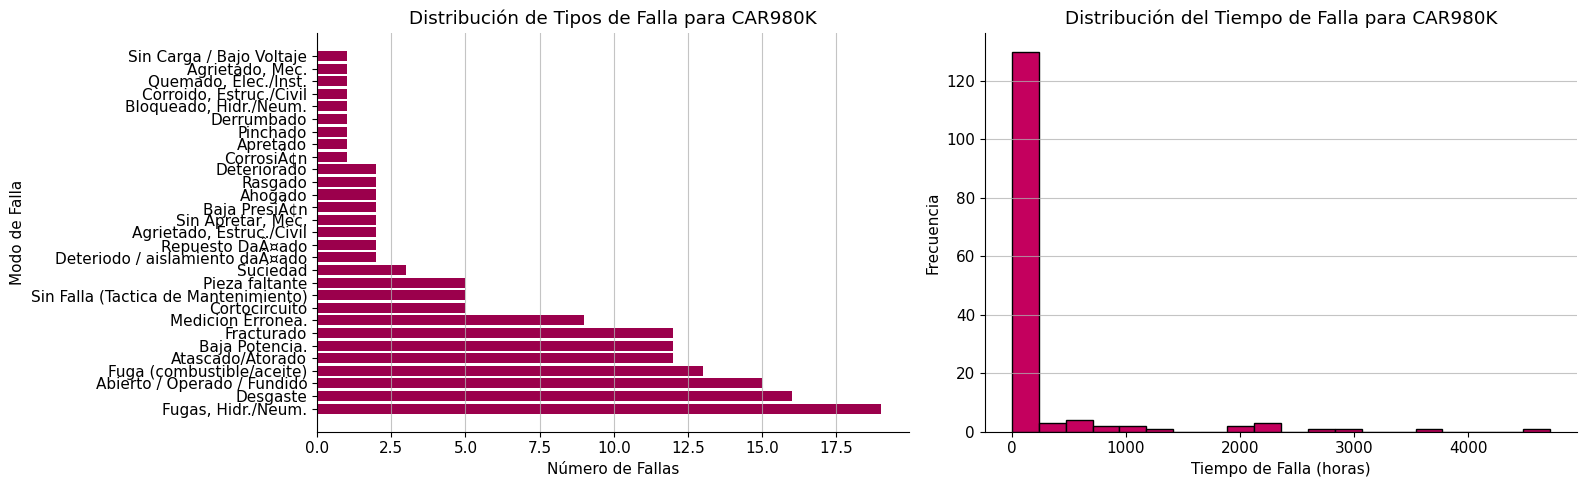


CONCLUSIÓN Y RECOMENDACIONES:
  El activo CAR980K muestra una criticidad extremadamente alta, con 151 fallas registradas y un costo total estimado de $4,285,429,167 USD. Lo más preocupante es su disponibilidad del 0.00% y MTBF de 0.0 horas, lo que indica que el activo está experimentando paradas constantes que consumen todo su tiempo operativo disponible.
  
  El modo de falla más frecuente es 'Fugas, Hidr./Neum.', lo que sugiere un problema recurrente y significativo en el sistema hidráulico/neumático de este cargador. Dada la magnitud del costo asociado y la nula disponibilidad, el CAR980K debe ser una prioridad absoluta en el programa de Mantenimiento Predictivo.

  Recomendaciones:
  1. Análisis Causa Raíz (ACR): Realizar un ACR profundo sobre las fallas de 'Fugas, Hidr./Neum.' para identificar las causas subyacentes y no solo reparar los síntomas.
  2. Monitoreo de Condición (CM): Implementar o reforzar el monitoreo de fluidos y sistemas hidráulicos/neumáticos (ej. análisis de ac

In [ ]:
# 🏋️ EJERCICIO INTEGRADOR — Análisis completo de un activo
# ============================================================

# Selecciona el activo a analizar
# Opciones: 'CAR980K', 'CAR980M', 'CAR938K', 'TRANVX8040',
#           'EXC320E', 'EXC320D', 'GRUALIEB', 'CAR950K'
ACTIVO = 'CAR980K'   # cambia este valor

# Filtrar datos del activo seleccionado
df_activo = df[df['Tipo_Activo'] == ACTIVO].copy()

print(f'📊 ANÁLISIS INTEGRADOR — {ACTIVO}')
print(f'   Total de OTs: {len(df_activo)}')
print()

# FASE 1 CRISP-DM: Comprensión del negocio
print('FASE 1: COMPRENSIÓN DEL NEGOCIO')
print(f'  Activo: {ACTIVO}')
print(f'  Problema: Reducir tiempo de paro no planificado')
print(f'  Pregunta: ¿Qué tipo de falla ocurre más y cuánto tiempo tarda?')
print()

# TODO: Calcula los KPIs del activo seleccionado
n_fallas = len(df_activo)
mttr_mediano = df_activo['Tiempo_Falla_h'].median()
tiempo_total_rep = df_activo['Tiempo_Falla_h'].sum()
tiempo_op = max(HORAS_DISPONIBLES - tiempo_total_rep, 0)
mtbf = tiempo_op / n_fallas if n_fallas > 0 else HORAS_DISPONIBLES # If no failures, MTBF is available hours
disponibilidad = (mtbf / (mtbf + mttr_mediano)) if (mtbf + mttr_mediano) > 0 else 0
costo_total = tiempo_total_rep * COSTO_HORA_USD

print('KPIs:')
print(f'  N° fallas:       {n_fallas}')
print(f'  MTTR mediano:    {mttr_mediano:.2f} horas')
print(f'  MTBF:            {mtbf:.1f} horas')
print(f'  Disponibilidad:  {disponibilidad*100:.2f}%')
print(f'  Costo total:     ${costo_total:,.0f} USD')
print()

# TODO: Tipo de falla más frecuente
tipo_falla_top = df_activo['Falla'].value_counts().index[0] if n_fallas > 0 else 'N/A'
print(f'Tipo de falla más frecuente: {tipo_falla_top}')
print()

# TODO: Genera 2 visualizaciones
# Sugerencia: 1) Barras de tipos de falla, 2) Histograma de tiempos

print('VISUALIZACIONES:')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Visualización 1: Barras de tipos de falla
falla_counts = df_activo['Falla'].value_counts()
axes[0].barh(falla_counts.index, falla_counts.values, color=COLOR_PRINCIPAL)
axes[0].set_title(f'Distribución de Tipos de Falla para {ACTIVO}')
axes[0].set_xlabel('Número de Fallas')
axes[0].set_ylabel('Modo de Falla')
axes[0].grid(axis='x', alpha=0.75)

# Visualización 2: Histograma de tiempos de falla
axes[1].hist(df_activo['Tiempo_Falla_h'], bins=20, color=COLOR_SECUNDARIO, edgecolor='black')
axes[1].set_title(f'Distribución del Tiempo de Falla para {ACTIVO}')
axes[1].set_xlabel('Tiempo de Falla (horas)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

print()
# TODO: Escribe tu conclusión
print('CONCLUSIÓN Y RECOMENDACIONES:')
print(f'''  El activo {ACTIVO} muestra una criticidad extremadamente alta, con {n_fallas} fallas registradas y un costo total estimado de ${costo_total:,.0f} USD. Lo más preocupante es su disponibilidad del {disponibilidad*100:.2f}% y MTBF de {mtbf:.1f} horas, lo que indica que el activo está experimentando paradas constantes que consumen todo su tiempo operativo disponible.

  El modo de falla más frecuente es '{tipo_falla_top}', lo que sugiere un problema recurrente y significativo en el sistema hidráulico/neumático de este cargador. Dada la magnitud del costo asociado y la nula disponibilidad, el {ACTIVO} debe ser una prioridad absoluta en el programa de Mantenimiento Predictivo.

  Recomendaciones:
  1. Análisis Causa Raíz (ACR): Realizar un ACR profundo sobre las fallas de '{tipo_falla_top}' para identificar las causas subyacentes y no solo reparar los síntomas.
  2. Monitoreo de Condición (CM): Implementar o reforzar el monitoreo de fluidos y sistemas hidráulicos/neumáticos (ej. análisis de aceite, termografía, ultrasonido) para detectar desviaciones temprano.
  3. Optimización del Mantenimiento: Revisar y optimizar los planes de mantenimiento preventivo específicos para los sistemas hidráulicos/neumáticos del {ACTIVO}, posiblemente aumentando la frecuencia de inspecciones o reemplazos de componentes críticos.
  4. Capacitación: Asegurar que el personal de mantenimiento esté capacitado en las mejores prácticas para la detección y reparación de fugas y problemas hidráulicos/neumáticos en este modelo específico.''')


CONCLUSIÓN Y RECOMENDACIONES para CAR980K:

El activo CAR980K muestra una criticidad extremadamente alta, con 151 fallas registradas y un costo total estimado de más de $4.2 mil millones de USD. Lo más preocupante es su disponibilidad del 0.00% y MTBF de 0.0 horas, lo que indica que el activo está experimentando paradas constantes que consumen todo su tiempo operativo disponible.

El modo de falla más frecuente es 'Fugas, Hidr./Neum.', lo que sugiere un problema recurrente y significativo en el sistema hidráulico/neumático de este cargador. Dada la magnitud del costo asociado y la nula disponibilidad, el CAR980K debe ser una prioridad absoluta en el programa de Mantenimiento Predictivo.

Recomendaciones:

Análisis Causa Raíz (ACR): Realizar un ACR profundo sobre las fallas de 'Fugas, Hidr./Neum.' para identificar las causas subyacentes y no solo reparar los síntomas.
Monitoreo de Condición (CM): Implementar o reforzar el monitoreo de fluidos y sistemas hidráulicos/neumáticos (ej. análisis de aceite, termografía, ultrasonido) para detectar desviaciones temprano.
Optimización del Mantenimiento: Revisar y optimizar los planes de mantenimiento preventivo específicos para los sistemas hidráulicos/neumáticos del CAR980K, posiblemente aumentando la frecuencia de inspecciones o reemplazos de componentes críticos.
Capacitación: Asegurar que el personal de mantenimiento esté capacitado en las mejores prácticas para la detección y reparación de fugas y problemas hidráulicos/neumáticos en este modelo específico.

---
# 📋 Resumen del Módulo 1

## Lo que aprendiste con datos reales:

| Tema | Herramienta Python | Resultado |
|------|-------------------|----------|
| **Aplicación del PdM** | `pd.read_csv()`, `groupby()`, `agg()` | Panorama real de la flota |
| **Introducción a Python** | `value_counts()`, filtros, `isin()`, visualización | Análisis exploratorio completo |
| **Problema Analítico** | Diccionarios, `describe()`, `quantile()` | Definición formal CRISP-DM |
| **KPIs y Criticidad** | `median()`, `sum()`, `iterrows()` | Dashboard de KPIs y Matriz de Criticidad |

## Referencias Verificadas:
- Chapman, P. et al. (2000). *CRISP-DM 1.0*. SPSS Inc.
- Moubray, J. (1997). *Reliability-Centered Maintenance*, 2nd ed. Industrial Press.
- ISO 14224:2016. *Collection and exchange of reliability and maintenance data for equipment.*
- ISO 55000:2024. *Asset Management*. Publicado: 3 julio 2024.
- ABB Value of Reliability Survey (2023). n=3,215 plantas industriales.
- McKinney, W. (2022). *Python for Data Analysis*, 3rd ed. O'Reilly.

---
**Ingenium Escuela de Formación Profesional** · 2026